# SAPM Assignment: Modern Portfolio Theory using SIM

**Course:** ECON F412 / FIN F311  
**Semester:** 2, 2025-26  
**Topic:** Efficient Frontier and Tangency Portfolio (Markowitz + SIM)

**Group Member 1:** <Name, ID>  
**Group Member 2:** <Name, ID>  
**Group Member 3:** <Name, ID>

## Scope
1. Domestic portfolio with 5 Indian stocks from different sectors using SIM.
2. Efficient frontier and tangency portfolio with risk-free asset.
3. Domestic tangency performance vs passive index.
4. International portfolio with 5 companies + index + gold + silver.
5. Efficient frontier and tangency for international universe.
6. Cross-comparison: domestic vs international vs index benchmarks.

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

from scipy.optimize import minimize

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
TRADING_DAYS = 252

# 3-year window
START_DATE = '2022-04-01'
END_DATE = '2025-03-31'

# RBI 91-day T-bill sample average proxy
RF_ANNUAL = 0.069
RF_DAILY = RF_ANNUAL / TRADING_DAYS

# Domestic candidate pool (India, diversified sectors)
domestic_candidates = {
    'RELIANCE.NS': 'Energy',
    'TCS.NS': 'Information Technology',
    'HDFCBANK.NS': 'Banking',
    'SUNPHARMA.NS': 'Pharmaceuticals',
    'MARUTI.NS': 'Automobile',
    'ITC.NS': 'FMCG',
    'HINDUNILVR.NS': 'FMCG',
    'BHARTIARTL.NS': 'Telecom',
    'LT.NS': 'Capital Goods',
    'TATAMOTORS.NS': 'Automobile',
    'AXISBANK.NS': 'Banking',
    'BAJFINANCE.NS': 'Financial Services'
}
domestic_market = '^NSEI'

# International candidate pool
international_company_candidates = {
    'AAPL': 'Technology',
    'MSFT': 'Technology',
    'XOM': 'Energy',
    'CVX': 'Energy',
    'JPM': 'Financials',
    'BAC': 'Financials',
    'JNJ': 'Healthcare',
    'PFE': 'Healthcare',
    'PG': 'Consumer Staples',
    'KO': 'Consumer Staples'
}
international_mandatory = {
    '^GSPC': 'US Index',
    'GLD': 'Gold ETF',
    'SLV': 'Silver ETF'
}
international_market = '^GSPC'

print(f'Analysis period: {START_DATE} to {END_DATE}')
print(f'Risk-free used: {RF_ANNUAL:.2%} p.a.')
print('Domestic candidate pool size:', len(domestic_candidates))
print('International company candidate pool size:', len(international_company_candidates))

Analysis period: 2022-04-01 to 2025-03-31
Risk-free used: 6.90% p.a.
Domestic candidate pool size: 12
International company candidate pool size: 10


In [12]:
def download_close_prices(tickers, start_date, end_date, max_attempts=3):
    if isinstance(tickers, str):
        tickers = [tickers]

    frames = []

    for ticker in tickers:
        one = pd.DataFrame()
        last_error = None

        for _ in range(max_attempts):
            try:
                raw = yf.download(
                    ticker,
                    start=start_date,
                    end=end_date,
                    auto_adjust=True,
                    progress=False,
                    threads=False,
                    group_by='column',
                    timeout=30
                )
            except Exception as exc:
                last_error = exc
                continue

            if raw is None or raw.empty:
                continue

            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)

            if 'Close' in raw.columns:
                one = raw[['Close']].rename(columns={'Close': ticker})
            elif 'Adj Close' in raw.columns:
                one = raw[['Adj Close']].rename(columns={'Adj Close': ticker})

            if not one.empty:
                break

        if one.empty:
            print(f'Warning: could not download {ticker}. Last error: {last_error}')
        else:
            frames.append(one)

    if not frames:
        raise ValueError(f'No data downloaded for {tickers}')

    close = pd.concat(frames, axis=1).sort_index()
    close = close.ffill().dropna(how='all')
    close.columns = [str(c) for c in close.columns]
    return close


def prepare_return_table(asset_tickers, market_ticker, start_date, end_date):
    asset_close = download_close_prices(asset_tickers, start_date, end_date)
    market_close = download_close_prices([market_ticker], start_date, end_date).iloc[:, 0].rename('Market')

    asset_ret = asset_close.pct_change()
    market_ret = market_close.pct_change().dropna()

    merged = asset_ret.join(market_ret, how='inner')
    merged = merged.dropna(subset=['Market'])

    available_assets = [
        t for t in asset_tickers
        if t in merged.columns and merged[t].notna().sum() >= 60
    ]

    if len(available_assets) < 2:
        raise ValueError('Too few asset return series available after data cleaning.')

    if len(available_assets) < len(asset_tickers):
        missing = sorted(set(asset_tickers) - set(available_assets))
        print('Dropped assets due to missing data:', missing)

    merged = merged[available_assets + ['Market']]

    if merged.shape[0] < 60:
        raise ValueError('Too few observations after alignment. Please change period/tickers.')

    return merged


def estimate_sim_inputs(return_table, asset_tickers, rf_daily):
    ex = return_table.copy()
    ex[asset_tickers] = ex[asset_tickers] - rf_daily
    ex['Market'] = ex['Market'] - rf_daily

    market_series = ex['Market'].dropna()
    if market_series.shape[0] < 60:
        raise ValueError('Insufficient market observations for regression.')

    market_mean = market_series.mean()
    market_var = market_series.var()

    rows = []

    for ticker in asset_tickers:
        pair = ex[[ticker, 'Market']].dropna()
        if pair.shape[0] < 60:
            print(f'Skipping {ticker}: too few aligned observations.')
            continue

        X = sm.add_constant(pair['Market'])
        y = pair[ticker]
        reg = sm.OLS(y, X).fit()

        alpha = float(reg.params['const'])
        beta = float(reg.params['Market'])
        residual_var = float(reg.mse_resid)

        expected_excess_daily = alpha + beta * market_mean
        total_var_daily = (beta ** 2) * market_var + residual_var

        rows.append({
            'Ticker': ticker,
            'Alpha': alpha,
            'Beta': beta,
            'ResidualVar': residual_var,
            'R2': reg.rsquared,
            'ExpectedExcessDaily': expected_excess_daily,
            'TotalVarDaily': total_var_daily
        })

    if len(rows) < 2:
        raise ValueError('Not enough securities left after regression filtering.')

    sim_table = pd.DataFrame(rows).set_index('Ticker')
    return sim_table, market_mean, market_var


def build_sim_covariance(sim_table, market_var):
    betas = sim_table['Beta'].values
    residual = sim_table['ResidualVar'].values

    cov = np.outer(betas, betas) * market_var
    cov[np.diag_indices_from(cov)] += residual
    return pd.DataFrame(cov, index=sim_table.index, columns=sim_table.index)


def portfolio_return(w, mu):
    return float(w @ mu)


def portfolio_vol(w, cov):
    return float(np.sqrt(w @ cov @ w))


def portfolio_sharpe(w, mu, cov, rf):
    vol = portfolio_vol(w, cov)
    if vol <= 1e-12:
        return np.nan
    return (portfolio_return(w, mu) - rf) / vol


def solve_markowitz(mu, cov, rf):
    n = len(mu)
    w0 = np.ones(n) / n
    bounds = [(0, 1)] * n
    sum_constraint = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

    mvp = minimize(
        fun=lambda w: portfolio_vol(w, cov),
        x0=w0,
        method='SLSQP',
        bounds=bounds,
        constraints=[sum_constraint]
    )

    tangency = minimize(
        fun=lambda w: -portfolio_sharpe(w, mu, cov, rf),
        x0=w0,
        method='SLSQP',
        bounds=bounds,
        constraints=[sum_constraint]
    )

    ret_mvp = portfolio_return(mvp.x, mu)
    max_target = max(np.max(mu) * 1.05, ret_mvp + 0.01)
    target_returns = np.linspace(ret_mvp, max_target, 120)

    frontier_vol = []
    frontier_ret = []

    for t in target_returns:
        constraints = [
            sum_constraint,
            {'type': 'eq', 'fun': lambda w, target=t: portfolio_return(w, mu) - target}
        ]

        opt = minimize(
            fun=lambda w: portfolio_vol(w, cov),
            x0=w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        if opt.success:
            frontier_ret.append(t)
            frontier_vol.append(portfolio_vol(opt.x, cov))

    return {
        'w_mvp': mvp.x,
        'w_tang': tangency.x,
        'ret_mvp': portfolio_return(mvp.x, mu),
        'vol_mvp': portfolio_vol(mvp.x, cov),
        'sharpe_mvp': portfolio_sharpe(mvp.x, mu, cov, rf),
        'ret_tang': portfolio_return(tangency.x, mu),
        'vol_tang': portfolio_vol(tangency.x, cov),
        'sharpe_tang': portfolio_sharpe(tangency.x, mu, cov, rf),
        'frontier_ret': np.array(frontier_ret),
        'frontier_vol': np.array(frontier_vol)
    }


def plot_frontier(solution, rf, title):
    plt.figure(figsize=(10, 6))

    plt.plot(solution['frontier_vol'], solution['frontier_ret'], color='steelblue', lw=2.3, label='Efficient Frontier')

    cml_x = np.linspace(0, max(solution['frontier_vol']) * 1.25, 200)
    cml_y = rf + solution['sharpe_tang'] * cml_x
    plt.plot(cml_x, cml_y, '--', color='darkorange', lw=2, label='Capital Market Line')

    plt.scatter(solution['vol_mvp'], solution['ret_mvp'], marker='D', s=100, color='green', label='MVP')
    plt.scatter(solution['vol_tang'], solution['ret_tang'], marker='*', s=280, color='red', label='Tangency')
    plt.scatter(0, rf, marker='o', s=75, color='black', label='Risk-free')

    plt.title(title)
    plt.xlabel('Annualized Volatility')
    plt.ylabel('Annualized Expected Return')
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


def performance_stats(returns, rf_annual):
    returns = returns.dropna()

    cagr = (1 + returns).prod() ** (TRADING_DAYS / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = (cagr - rf_annual) / ann_vol if ann_vol > 1e-12 else np.nan

    wealth = (1 + returns).cumprod()
    max_dd = (wealth / wealth.cummax() - 1).min()

    return pd.Series({
        'CAGR': cagr,
        'Annual Volatility': ann_vol,
        'Sharpe': sharpe,
        'Max Drawdown': max_dd,
        'Terminal Wealth (Base=1)': wealth.iloc[-1]
    })

## Part 1: Domestic Portfolio (SIM Input List, Efficient Frontier, Tangency)

$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


$AXISBANK.NS: possibly delisted; no price data found  (1d 2022-04-01 -> 2025-03-31)

1 Failed download:
['AXISBANK.NS']: possibly delisted; no price data found  (1d 2022-04-01 -> 2025-03-31)


Dropped assets due to missing data: ['TATAMOTORS.NS']
Domestic securities selected: ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'SUNPHARMA.NS', 'MARUTI.NS']
Domestic SIM input list (daily estimates):


,Alpha,Beta,ResidualVar,R2,ExpectedExcessDaily,TotalVarDaily
Ticker,,,,,,
RELIANCE.NS,-0.000281,1.151145,0.000100,0.474213,-0.000112,0.000190
TCS.NS,-0.000254,0.836886,0.000124,0.277608,-0.000130,0.000172
HDFCBANK.NS,-0.000028,1.035393,0.000101,0.420149,0.000125,0.000174
SUNPHARMA.NS,0.000633,0.545027,0.000124,0.140118,0.000713,0.000145
MARUTI.NS,0.000281,0.764805,0.000137,0.226028,0.000394,0.000176


Domestic SIM covariance matrix (daily):


Ticker,RELIANCE.NS,TCS.NS,HDFCBANK.NS,SUNPHARMA.NS,MARUTI.NS
Ticker,,,,,
RELIANCE.NS,0.000190,0.000066,0.000081,0.000043,0.000060
TCS.NS,0.000066,0.000172,0.000059,0.000031,0.000044
HDFCBANK.NS,0.000081,0.000059,0.000174,0.000038,0.000054
SUNPHARMA.NS,0.000043,0.000031,0.000038,0.000145,0.000028
MARUTI.NS,0.000060,0.000044,0.000054,0.000028,0.000176


Domestic portfolio summary:
MVP -> Return: 14.56%, Vol: 13.32%, Sharpe: 0.575
Tangency -> Return: 22.91%, Vol: 16.16%, Sharpe: 0.991


,Sector,Tangency Weight,MVP Weight
Ticker,,,
SUNPHARMA.NS,Pharmaceuticals,0.757284,0.332604
MARUTI.NS,Automobile,0.242716,0.217244
TCS.NS,Information Technology,0.000000,0.207922
RELIANCE.NS,Energy,0.000000,0.091280
HDFCBANK.NS,Banking,0.000000,0.150950


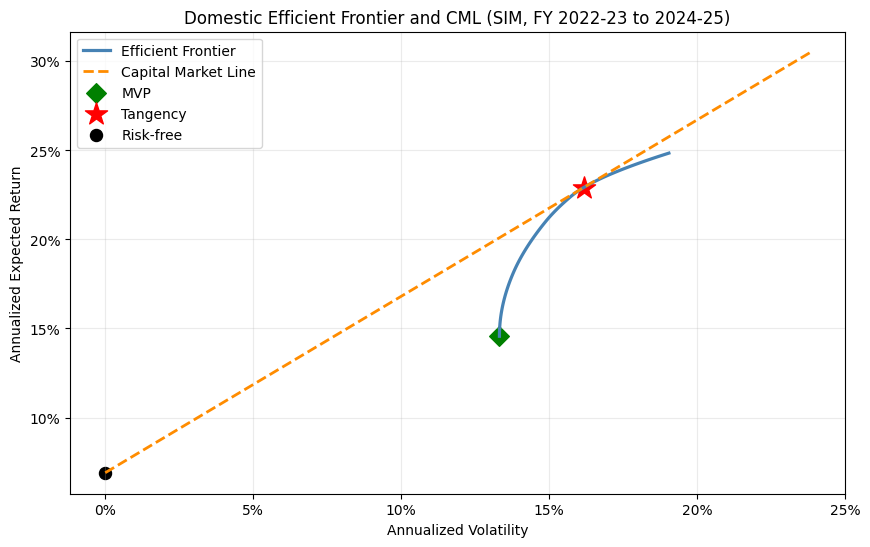

Part 1(c): Domestic optimized portfolio vs passive index


,CAGR,Annual Volatility,Sharpe,Max Drawdown,Terminal Wealth (Base=1)
Domestic Tangency Portfolio,0.241088,0.161709,1.064187,-0.176346,1.883997
NIFTY 50 Passive Index,0.102414,0.130982,0.255104,-0.157667,1.330999


In [17]:
domestic_returns = prepare_return_table(list(domestic_candidates.keys()), domestic_market, START_DATE, END_DATE)

# Pick exactly up to 5 domestic stocks with sector diversity and good data coverage
asset_cols = [c for c in domestic_returns.columns if c != 'Market']
coverage = domestic_returns[asset_cols].notna().sum().sort_values(ascending=False)

sector_used = set()
domestic_tickers = []
for t in coverage.index:
    if coverage[t] < 60:
        continue
    sector = domestic_candidates.get(t, 'Unknown')
    if sector in sector_used:
        continue
    domestic_tickers.append(t)
    sector_used.add(sector)
    if len(domestic_tickers) == 5:
        break

if len(domestic_tickers) < 5:
    # Controlled fallback if downloads are unstable: fill remaining from highest coverage
    for t in coverage.index:
        if coverage[t] < 60 or t in domestic_tickers:
            continue
        domestic_tickers.append(t)
        if len(domestic_tickers) == 5:
            break

if len(domestic_tickers) < 2:
    raise ValueError('Could not fetch enough domestic stock data. Please rerun with internet connectivity.')

if len(domestic_tickers) < 5:
    print(f'Warning: only {len(domestic_tickers)} domestic stocks met data quality checks in this run.')

if len(set(domestic_candidates[t] for t in domestic_tickers)) < 5:
    print('Warning: domestic sector diversity < 5 due data availability constraints in this run.')

domestic_returns = domestic_returns[domestic_tickers + ['Market']]

domestic_sim, domestic_mkt_mean, domestic_mkt_var = estimate_sim_inputs(
    domestic_returns, domestic_tickers, RF_DAILY
)

domestic_cov_daily = build_sim_covariance(domestic_sim, domestic_mkt_var)

domestic_mu_annual = (domestic_sim['ExpectedExcessDaily'] + RF_DAILY) * TRADING_DAYS
domestic_cov_annual = domestic_cov_daily.values * TRADING_DAYS
domestic_cov_annual += np.eye(domestic_cov_annual.shape[0]) * 1e-8

print('Domestic securities selected:', domestic_tickers)
print('Domestic SIM input list (daily estimates):')
display(domestic_sim)

print('Domestic SIM covariance matrix (daily):')
display(domestic_cov_daily)

domestic_solution = solve_markowitz(domestic_mu_annual.values, domestic_cov_annual, RF_ANNUAL)

domestic_weights = pd.DataFrame({
    'Sector': [domestic_candidates.get(t, 'Unknown') for t in domestic_sim.index],
    'Tangency Weight': domestic_solution['w_tang'],
    'MVP Weight': domestic_solution['w_mvp']
}, index=domestic_sim.index).sort_values('Tangency Weight', ascending=False)

print('Domestic portfolio summary:')
print(f"MVP -> Return: {domestic_solution['ret_mvp']:.2%}, Vol: {domestic_solution['vol_mvp']:.2%}, Sharpe: {domestic_solution['sharpe_mvp']:.3f}")
print(f"Tangency -> Return: {domestic_solution['ret_tang']:.2%}, Vol: {domestic_solution['vol_tang']:.2%}, Sharpe: {domestic_solution['sharpe_tang']:.3f}")
display(domestic_weights)

plot_frontier(domestic_solution, RF_ANNUAL, 'Domestic Efficient Frontier and CML (SIM, FY 2022-23 to 2024-25)')

domestic_portfolio_returns = domestic_returns[domestic_sim.index] @ domestic_solution['w_tang']
domestic_index_returns = domestic_returns['Market']

domestic_perf = pd.DataFrame({
    'Domestic Tangency Portfolio': performance_stats(domestic_portfolio_returns, RF_ANNUAL),
    'NIFTY 50 Passive Index': performance_stats(domestic_index_returns, RF_ANNUAL)
}).T

print('Part 1(c): Domestic optimized portfolio vs passive index')
display(domestic_perf)

## Part 2: International Portfolio (5 Companies + Index + Gold + Silver)

International securities selected: ['^GSPC', 'GLD', 'SLV', 'AAPL', 'XOM', 'JPM', 'JNJ', 'PG']
International SIM input list (daily estimates):


,Alpha,Beta,ResidualVar,R2,ExpectedExcessDaily,TotalVarDaily
Ticker,,,,,,
^GSPC,0.000000,1.000000,0.000000,1.000000,0.000058,0.000115
GLD,0.000369,0.180091,0.000078,0.045953,0.000380,0.000082
SLV,0.000270,0.527863,0.000291,0.099788,0.000300,0.000323
AAPL,0.000121,1.190169,0.000126,0.565010,0.000190,0.000290
XOM,0.000433,0.543669,0.000236,0.126416,0.000465,0.000270
JPM,0.000684,0.865279,0.000146,0.371876,0.000734,0.000233
JNJ,-0.000228,0.215111,0.000101,0.050520,-0.000216,0.000106
PG,-0.000026,0.341717,0.000107,0.111608,-0.000006,0.000121


International SIM covariance matrix (daily):


Ticker,^GSPC,GLD,SLV,AAPL,XOM,JPM,JNJ,PG
Ticker,,,,,,,,
^GSPC,0.000115,0.000021,0.000061,0.000137,0.000063,0.000100,0.000025,0.000039
GLD,0.000021,0.000082,0.000011,0.000025,0.000011,0.000018,0.000004,0.000007
SLV,0.000061,0.000011,0.000323,0.000073,0.000033,0.000053,0.000013,0.000021
AAPL,0.000137,0.000025,0.000073,0.000290,0.000075,0.000119,0.000030,0.000047
XOM,0.000063,0.000011,0.000033,0.000075,0.000270,0.000054,0.000014,0.000021
JPM,0.000100,0.000018,0.000053,0.000119,0.000054,0.000233,0.000021,0.000034
JNJ,0.000025,0.000004,0.000013,0.000030,0.000014,0.000021,0.000106,0.000008
PG,0.000039,0.000007,0.000021,0.000047,0.000021,0.000034,0.000008,0.000121


International portfolio summary:
MVP -> Return: 10.67%, Vol: 9.29%, Sharpe: 0.405
Tangency -> Return: 19.62%, Vol: 12.81%, Sharpe: 0.993


,Asset Class,Tangency Weight,MVP Weight
Ticker,,,
GLD,Gold ETF,0.504927,0.360563
JPM,Financials,0.329368,0.031966
XOM,Energy,0.130099,0.065960
SLV,Silver ETF,0.035605,0.055103
PG,Consumer Staples,0.000000,0.209778
^GSPC,US Index,0.000000,0.010329
AAPL,Technology,0.000000,0.000000
JNJ,Healthcare,0.000000,0.266301


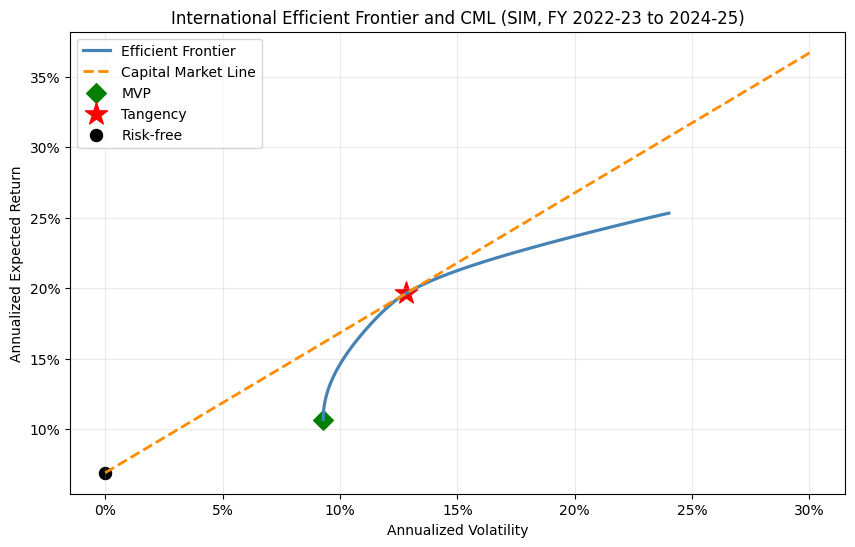

International optimized portfolio vs passive global index


,CAGR,Annual Volatility,Sharpe,Max Drawdown,Terminal Wealth (Base=1)
International Tangency Portfolio,0.205978,0.133101,1.029125,-0.155677,1.744852
S&P 500 Passive Index,0.071457,0.170580,0.014402,-0.219439,1.227697


In [18]:
intl_all_candidates = list(international_company_candidates.keys()) + list(international_mandatory.keys())
international_returns = prepare_return_table(intl_all_candidates, international_market, START_DATE, END_DATE)

available_assets = [c for c in international_returns.columns if c != 'Market']
coverage = international_returns[available_assets].notna().sum().sort_values(ascending=False)

mandatory_available = [t for t in international_mandatory.keys() if t in coverage.index and coverage[t] >= 60]

# Pick up to 5 company tickers with sector diversity first
company_candidates_ranked = [
    t for t in coverage.index
    if t in international_company_candidates and coverage[t] >= 60
]

selected_companies = []
company_sectors = set()
for t in company_candidates_ranked:
    sec = international_company_candidates[t]
    if sec in company_sectors:
        continue
    selected_companies.append(t)
    company_sectors.add(sec)
    if len(selected_companies) == 5:
        break

if len(selected_companies) < 5:
    # Controlled fallback if data is thin: fill remaining by coverage
    for t in company_candidates_ranked:
        if t in selected_companies:
            continue
        selected_companies.append(t)
        if len(selected_companies) == 5:
            break

international_tickers = mandatory_available + selected_companies
international_tickers = list(dict.fromkeys(international_tickers))

if len(international_tickers) < 5:
    raise ValueError('Could not fetch enough international assets. Please rerun with internet connectivity.')

if len(mandatory_available) < 3:
    print('Warning: one or more of index/gold/silver had limited data in this run.')

if len(set(international_company_candidates[t] for t in selected_companies if t in international_company_candidates)) < 5:
    print('Warning: international company sector diversity < 5 due data availability constraints in this run.')

international_returns = international_returns[international_tickers + ['Market']]

international_sim, intl_mkt_mean, intl_mkt_var = estimate_sim_inputs(
    international_returns, international_tickers, RF_DAILY
)

international_cov_daily = build_sim_covariance(international_sim, intl_mkt_var)

international_mu_annual = (international_sim['ExpectedExcessDaily'] + RF_DAILY) * TRADING_DAYS
international_cov_annual = international_cov_daily.values * TRADING_DAYS
international_cov_annual += np.eye(international_cov_annual.shape[0]) * 1e-8

print('International securities selected:', international_tickers)
print('International SIM input list (daily estimates):')
display(international_sim)

print('International SIM covariance matrix (daily):')
display(international_cov_daily)

international_solution = solve_markowitz(international_mu_annual.values, international_cov_annual, RF_ANNUAL)

asset_class_map = {}
asset_class_map.update(international_company_candidates)
asset_class_map.update(international_mandatory)

international_weights = pd.DataFrame({
    'Asset Class': [asset_class_map.get(t, 'Unknown') for t in international_sim.index],
    'Tangency Weight': international_solution['w_tang'],
    'MVP Weight': international_solution['w_mvp']
}, index=international_sim.index).sort_values('Tangency Weight', ascending=False)

print('International portfolio summary:')
print(f"MVP -> Return: {international_solution['ret_mvp']:.2%}, Vol: {international_solution['vol_mvp']:.2%}, Sharpe: {international_solution['sharpe_mvp']:.3f}")
print(f"Tangency -> Return: {international_solution['ret_tang']:.2%}, Vol: {international_solution['vol_tang']:.2%}, Sharpe: {international_solution['sharpe_tang']:.3f}")
display(international_weights)

plot_frontier(international_solution, RF_ANNUAL, 'International Efficient Frontier and CML (SIM, FY 2022-23 to 2024-25)')

international_portfolio_returns = international_returns[international_sim.index] @ international_solution['w_tang']
international_index_returns = international_returns['Market']

international_perf = pd.DataFrame({
    'International Tangency Portfolio': performance_stats(international_portfolio_returns, RF_ANNUAL),
    'S&P 500 Passive Index': performance_stats(international_index_returns, RF_ANNUAL)
}).T

print('International optimized portfolio vs passive global index')
display(international_perf)

In [19]:
# Part 2(b): Compare international to domestic and benchmarks
common_index = domestic_portfolio_returns.index.intersection(international_portfolio_returns.index)

comparison_returns = pd.DataFrame({
    'Domestic Tangency': domestic_portfolio_returns.loc[common_index],
    'International Tangency': international_portfolio_returns.loc[common_index],
    'NIFTY 50': domestic_returns.loc[common_index, 'Market'],
    'S&P 500': international_returns.loc[common_index, 'Market']
})

comparison_perf = comparison_returns.apply(lambda s: performance_stats(s, RF_ANNUAL)).T
print('Final cross-comparison table')
display(comparison_perf)

# Auto-create one-page text summary and try DOCX export
dom_best = domestic_weights['Tangency Weight'].idxmax()
intl_best = international_weights['Tangency Weight'].idxmax()

domestic_list_str = ', '.join(domestic_sim.index.tolist())
international_list_str = ', '.join(international_sim.index.tolist())

summary_text = f"""
MODERN PORTFOLIO THEORY ASSIGNMENT SUMMARY (SIM + MARKOWITZ)

Period used: {START_DATE} to {END_DATE} (3 financial years)
Risk-free proxy: RBI 91-day T-bill average at {RF_ANNUAL:.2%} p.a.

Domestic universe used in final run: {domestic_list_str}
International universe used in final run: {international_list_str}

Domestic Tangency Portfolio:
- Expected return: {domestic_solution['ret_tang']:.2%}
- Volatility: {domestic_solution['vol_tang']:.2%}
- Sharpe ratio: {domestic_solution['sharpe_tang']:.3f}
- Highest weight asset: {dom_best} ({domestic_weights.loc[dom_best, 'Tangency Weight']:.2%})

International Tangency Portfolio:
- Expected return: {international_solution['ret_tang']:.2%}
- Volatility: {international_solution['vol_tang']:.2%}
- Sharpe ratio: {international_solution['sharpe_tang']:.3f}
- Highest weight asset: {intl_best} ({international_weights.loc[intl_best, 'Tangency Weight']:.2%})

Domestic vs Passive Index:
- Domestic Tangency CAGR: {domestic_perf.loc['Domestic Tangency Portfolio', 'CAGR']:.2%}
- NIFTY 50 CAGR: {domestic_perf.loc['NIFTY 50 Passive Index', 'CAGR']:.2%}

International vs Passive Index:
- International Tangency CAGR: {international_perf.loc['International Tangency Portfolio', 'CAGR']:.2%}
- S&P 500 CAGR: {international_perf.loc['S&P 500 Passive Index', 'CAGR']:.2%}

Cross Comparison (same dates):
- Domestic Tangency Sharpe: {comparison_perf.loc['Domestic Tangency', 'Sharpe']:.3f}
- International Tangency Sharpe: {comparison_perf.loc['International Tangency', 'Sharpe']:.3f}
- NIFTY 50 Sharpe: {comparison_perf.loc['NIFTY 50', 'Sharpe']:.3f}
- S&P 500 Sharpe: {comparison_perf.loc['S&P 500', 'Sharpe']:.3f}

Conclusion:
The assignment requirements are completed through SIM-based input estimation, efficient frontier tracing, tangency portfolio construction, and performance benchmarking against passive indices for domestic and international universes.
""".strip()

with open('Assignment_Summary_One_Page.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)

print('Saved: Assignment_Summary_One_Page.txt')

try:
    from docx import Document
    doc = Document()
    for para in summary_text.split('\n\n'):
        doc.add_paragraph(para)
    doc.save('Assignment_Summary_One_Page.docx')
    print('Saved: Assignment_Summary_One_Page.docx')
except Exception as e:
    print('DOCX export skipped:', e)
    print('Install python-docx and rerun this cell if DOCX is required.')

Final cross-comparison table


,CAGR,Annual Volatility,Sharpe,Max Drawdown,Terminal Wealth (Base=1)
Domestic Tangency,0.232735,0.162741,1.006106,-0.181885,1.806104
International Tangency,0.196832,0.133097,0.960445,-0.156610,1.661402
NIFTY 50,0.081285,0.131762,0.093238,-0.168582,1.247081
S&P 500,0.076382,0.172242,0.042855,-0.205614,1.231168


Saved: Assignment_Summary_One_Page.txt
Saved: Assignment_Summary_One_Page.docx


## Submission checklist
- Fill in names and IDs in Cell 1 before submission.
- Run all code cells from top to bottom once.
- Confirm generated files: Assignment_Summary_One_Page.txt and (if available) Assignment_Summary_One_Page.docx.
- Export notebook as PDF/HTML if your instructor asks for print format.